# Task 3.1.2
Autoencoder

In [5]:
import numpy as np
import matplotlib.pyplot

In [19]:
# np.info(np.where)
# np.info(np.random.randn)

In [ ]:
patterns = np.eye(8) * 2 -1
targets = patterns.copy()
print(patterns.shape)


def phi(z):
    return np.tanh(z)

def phi_prime(z):
    return 1-np.tanh(z)**2

input_layer = 8
hidden_layer = 3
output_layer = 8
learning_rate = 0.1

np.random.seed(0)

W1 = np.random.randn(input_layer, hidden_layer) * 0.1
W2 = np.random.randn(hidden_layer, output_layer) * 0.1
b1 = np.zeros((1, hidden_layer))
b2 = np.zeros((1, output_layer))

epochs = 1000

for epoch in range(epochs):
    total_error = 0
    for i in range(len(patterns)):
        ## Forward
        x = patterns[i:i+1]
        hidden_input = x@W1 + b1
        hidden_output = phi(hidden_input)
        
        final_input = hidden_output @ W2 + b2
        final_output = phi(final_input)
        
        ## Backward
        t = targets[i:i+1]
        error = t-final_output
        total_error += np.sum(error ** 2)
        delta_output = error * phi_prime(final_input)
        delta_hidden = delta_output @ W2.T * phi_prime(hidden_input)
        
        ## Weight update
        W2 += learning_rate * hidden_output.T @ delta_output
        b2 += learning_rate * delta_output
        W1 += learning_rate * x.T @ delta_hidden
        b1 += learning_rate * delta_hidden
        
    all_hidden = phi(patterns @ W1 + b1)
    all_output = phi(all_hidden@ W2 + b2)
    # print(epoch)
    if np.array_equal(np.sign(all_output), np.sign(targets)):
        print(f"Converged at epoch {epoch}")
        break

h_activations = phi(patterns@W1 + b1)
for i in range(8):
    code = np.sign(h_activations[i])
    print(f"Pattern {i+1} | {code}")
print("\n--- Weight Inspection (W1) ---")
print(np.round(W1, 2))
    

        
        
        
        
         



(8, 8)
Converged at epoch 6902
Pattern 1 | [1. 1.]
Pattern 2 | [-1.  1.]
Pattern 3 | [ 1. -1.]
Pattern 4 | [ 1. -1.]
Pattern 5 | [-1. -1.]
Pattern 6 | [1. 1.]
Pattern 7 | [-1.  1.]
Pattern 8 | [-1. -1.]

--- Weight Inspection (W1) ---
[[ 2.64  0.55]
 [-1.32  0.48]
 [ 0.19 -2.56]
 [ 2.27 -0.43]
 [-2.97 -0.4 ]
 [ 0.21  2.86]
 [-0.6   2.02]
 [-0.77 -2.39]]


In [ ]:
def encode(input_pattern):
    """
    Takes an 8-dim input and compresses it to a 3-dim code.
    Uses W1 and b1.
    """
    hidden_input = input_pattern @ W1 + b1
    code = phi(hidden_input)
    return code

def decode(code):
    """
    Takes a 3-dim code and reconstructs the 8-dim pattern.
    Uses W2 and b2.
    """
    final_input = code @ W2 + b2
    reconstruction = phi(final_input)
    return reconstruction


original_pattern = patterns[1:2] 

print("Original Input:")
print(original_pattern)

my_compressed_code = encode(original_pattern)
print("\nEncoded (Compressed) Representation:")
print(my_compressed_code) 

restored_pattern = decode(my_compressed_code)
print("\nDecoded (Restored) Output:")
print(np.sign(restored_pattern))

Original Input:
[[-1.  1. -1. -1. -1. -1. -1. -1.]]

Encoded (Compressed) Representation:
[[-0.97161051  0.6966626 ]]

Decoded (Restored) Output:
[[-1.  1. -1. -1. -1. -1. -1. -1.]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# ============================================================
# 1. Generate Mackey–Glass time series
# ============================================================

beta = 0.2
gamma = 0.1
n = 10
tau = 25

T = 1600

x = np.zeros(T)
x[0] = 1.5  # initial condition

# Euler discretisation of Mackey–Glass equation
for t in range(T - 1):
    if t - tau >= 0:
        x_tau = x[t - tau]
    else:
        x_tau = 0.0

    x[t + 1] = x[t] + (
        beta * x_tau / (1 + x_tau**n)
        - gamma * x[t]
    )

# ============================================================
# 2. Visualise the time series
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(x)
plt.title("Mackey–Glass Time Series")
plt.xlabel("Time t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

# ============================================================
# 3. Construct embedded input-output dataset
# ============================================================

t = np.arange(301, 1501)

# Embedded input vector:
# [x(t-20), x(t-15), x(t-10), x(t-5), x(t)]
inputs = np.vstack([
    x[t - 20],
    x[t - 15],
    x[t - 10],
    x[t - 5],
    x[t]
])

targets = x[t + 5]

X = inputs.T              
y = targets.reshape(-1, 1)  

print("Input shape:", X.shape)
print("Target shape:", y.shape)

# ============================================================
# 4. Split into training, validation, and test sets
# ============================================================

n_test = 200
n_train = 800
n_val = 200

X_train = X[:n_train]
y_train = y[:n_train]

X_val = X[n_train:n_train + n_val]
y_val = y[n_train:n_train + n_val]

X_test = X[-n_test:]
y_test = y[-n_test:]

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test.shape[0])

Train Shape: (800, 5)
Val Shape:   (200, 5)
Test Shape:  (200, 5)


nh1   nh2   lam        | Val MSE   
-----------------------------------
3     2     0.0001     | 0.04847
3     4     0.0001     | 0.05227
3     6     0.0001     | 0.01858
3     8     0.0001     | 0.01978
4     2     0.0001     | 0.04964
4     4     0.0001     | 0.01719
4     6     0.0001     | 0.04685
4     8     0.0001     | 0.01948
5     2     0.0001     | 0.03967
5     4     0.0001     | 0.01414
5     6     0.0001     | 0.01396
5     8     0.0001     | 0.01893
6     2     0.0001     | 0.01901
6     4     0.0001     | 0.04432
6     6     0.0001     | 0.01732
6     8     0.0001     | 0.02021
7     2     0.0001     | 0.02458
7     4     0.0001     | 0.01796
7     6     0.0001     | 0.01190
7     8     0.0001     | 0.01494
8     2     0.0001     | 0.01676
8     4     0.0001     | 0.01929
8     6     0.0001     | 0.01328
8     8     0.0001     | 0.01860
3     2     0.001      | 0.02632
3     4     0.001      | 0.05955
3     6     0.001      | 0.01957
3     8     0.001      | 0.02533
4   

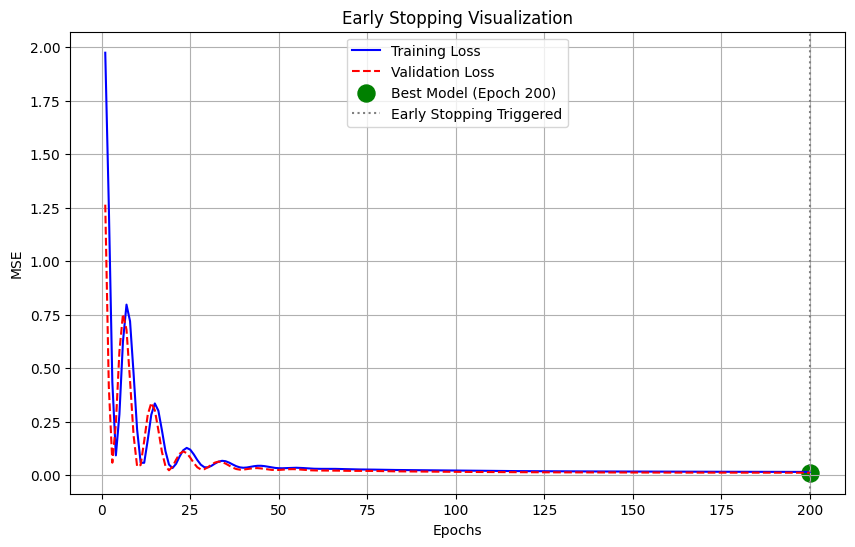


--- Final Test Evaluation ---
Final Test MSE: 0.019919
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


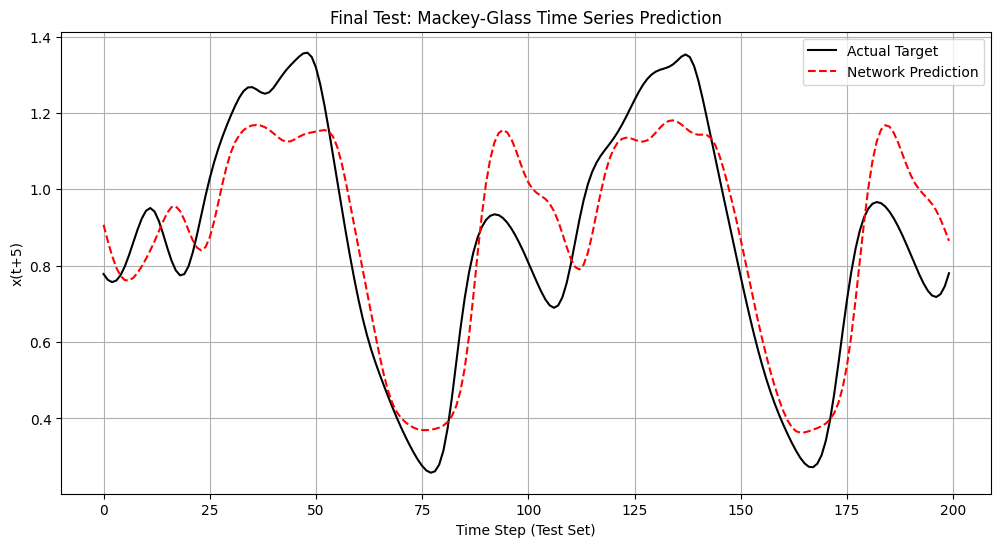

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks, optimizers
import matplotlib.pyplot as plt
import numpy as np

def plot_early_stopping(history, patience_value):
    """
    Plots training and validation loss to visualize Early Stopping.
    """
    loss_train = history.history['loss']
    loss_val = history.history['val_loss']
    epochs = range(1, len(loss_train) + 1)
    
    # Identify the best epoch (where weights were restored from)
    best_epoch_idx = np.argmin(loss_val)
    best_epoch = best_epoch_idx + 1 
    best_val_loss = loss_val[best_epoch_idx]
    stop_epoch = len(loss_train)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, loss_train, 'b-', label='Training Loss')
    plt.plot(epochs, loss_val, 'r--', label='Validation Loss') 
    
    plt.scatter(best_epoch, best_val_loss, s=150, c='green', marker='o', 
                label=f'Best Model (Epoch {best_epoch})')
    
    plt.axvline(x=stop_epoch, color='gray', linestyle=':', label='Early Stopping Triggered')
    
    if stop_epoch > best_epoch:
        plt.annotate('', xy=(best_epoch, best_val_loss), xytext=(stop_epoch, best_val_loss),
                     arrowprops=dict(arrowstyle='<->', color='black'))
        plt.text((best_epoch + stop_epoch)/2, best_val_loss * 1.05, 
                 f'Patience ({patience_value})', ha='center')

    plt.title('Early Stopping Visualization')
    plt.xlabel('Epochs')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_test_predictions(y_true, y_pred):
    """
    Plots the final test predictions vs known targets.
    Required by[cite: 296].
    """
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, 'k-', label='Actual Target', linewidth=1.5)
    plt.plot(y_pred, 'r--', label='Network Prediction', linewidth=1.5)
    plt.title('Final Test: Mackey-Glass Time Series Prediction')
    plt.xlabel('Time Step (Test Set)')
    plt.ylabel('x(t+5)')
    plt.legend()
    plt.grid(True)
    plt.show()

def build_and_train_model(X_train, y_train, X_val, y_val, 
                          nh1, nh2, lambda_reg):
    """
    Builds a 3-layer perceptron with specified nodes and regularization.
    """
    model = models.Sequential()
    
    model.add(layers.Dense(nh1, activation='tanh', input_dim=5,
                           kernel_regularizer=regularizers.l2(lambda_reg)))
    model.add(layers.Dense(nh2, activation='tanh',
                           kernel_regularizer=regularizers.l2(lambda_reg)))
    model.add(layers.Dense(1, activation='linear',
                           kernel_regularizer=regularizers.l2(lambda_reg)))
    optimizer = optimizers.SGD(learning_rate=0.01, momentum=0.9)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    early_stop = callbacks.EarlyStopping(monitor='val_loss', 
                                         patience=50, 
                                         restore_best_weights=True)
    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=200, 
                        batch_size=len(X_train), 
                        callbacks=[early_stop],
                        verbose=0)
                        
    return model, history

# ====================================
# Permutation: num nodes in layer 1, layer 2 and lambda 
# ====================================
nh1_options = [3, 4, 5, 6, 7, 8]
nh2_options = [2, 4, 6, 8]
lambda_options = [0.0001, 0.001] 


best_error = float('inf')
best_config = None # Will store (nh1, nh2, lambda)
best_model_weights = None

print(f"{'nh1':<5} {'nh2':<5} {'lam':<10} | {'Val MSE':<10}")
print("-" * 35)

for lam in lambda_options:
    for h1 in nh1_options:
        for h2 in nh2_options:
            model, hist = build_and_train_model(X_train, y_train, X_val, y_val, 
                                                nh1=h1, nh2=h2, lambda_reg=lam)
            val_loss = min(hist.history['val_loss'])
            print(f"{h1:<5} {h2:<5} {lam:<10} | {val_loss:.5f}")
            
            if val_loss < best_error:
                best_error = val_loss
                best_config = (h1, h2, lam)
                best_model_weights = model.get_weights()
                best_history = hist

print("-" * 35)
print(f"WINNER: nh1={best_config[0]}, nh2={best_config[1]}, lambda={best_config[2]}")
print(f"Best Validation MSE: {best_error:.6f}")

print("\nPlotting Early Stopping for the Best Configuration...")
plot_early_stopping(best_history, patience_value=50)
print("\n--- Final Test Evaluation ---")

final_model, _ = build_and_train_model(X_train, y_train, X_val, y_val,
                                       nh1=best_config[0], 
                                       nh2=best_config[1], 
                                       lambda_reg=best_config[2])

# ==========================
# Configure the model with the best config found during gridy search
# ==========================
final_model.set_weights(best_model_weights)

# =========================
# Final test on unseen data with best configuration
# =========================
test_loss = final_model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test MSE: {test_loss:.6f}")

predictions = final_model.predict(X_test)
plot_test_predictions(y_test, predictions)

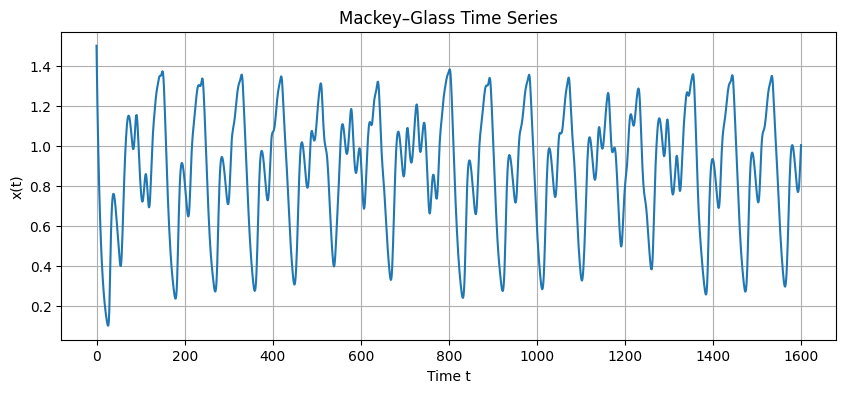

Input shape: (1200, 5)
Target shape: (1200, 1)
Training samples: 800
Validation samples: 200
Test samples: 200


f:\repositories\CAREER\MachineLearningPortfolio\exercises\neural_network\.my_ann_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_147 (Dense)               │ (None, 8)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_148 (Dense)               │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_149 (Dense)               │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109 (436.00 B)

 Trainable params: 109 (436.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step - loss: 1.0238 - val_loss: 0.7337
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.7268 - val_loss: 0.4913
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.4952 - val_loss: 0.3120
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.3257 - val_loss: 0.1893
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.2118 - val_loss: 0.1150
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.1451 - val_loss: 0.0791
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.1156 - val_loss: 0.0699
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.1114 - val_loss: 0.0757
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.1206 - val_loss: 0.0863
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.1330 - val_loss: 0.0949
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.1421 - val_loss: 0.0983
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.1449 - val_l

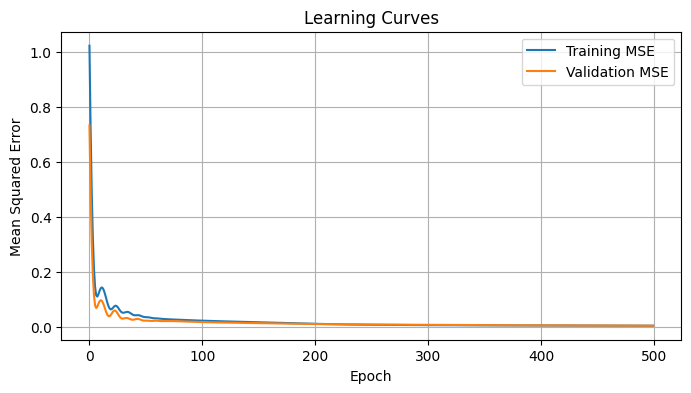

Test MSE: 0.006055
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


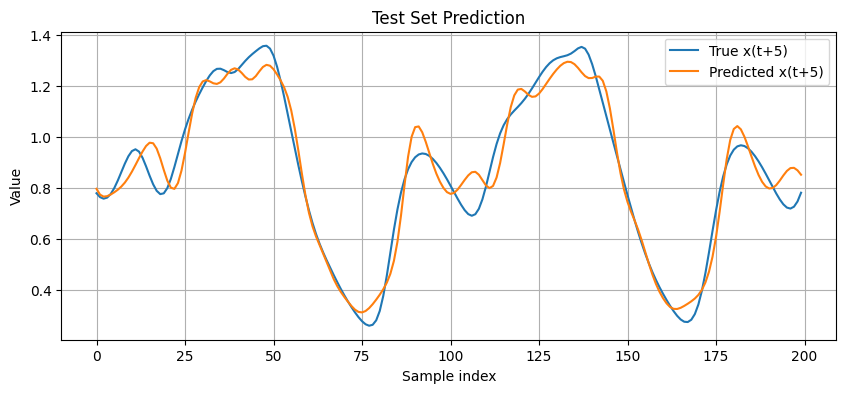

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# ============================================================
# 1. Generate Mackey–Glass time series
# ============================================================

# Parameters specified in the lab manual
beta = 0.2
gamma = 0.1
n = 10
tau = 25

# Length of the generated time series
# Must be longer than 1505 to allow embedding
T = 1600

# Initialise time series
x = np.zeros(T)
x[0] = 1.5  # initial condition
# For t < 0, x(t) = 0 is already satisfied

# Euler discretisation of Mackey–Glass equation
for t in range(T - 1):
    if t - tau >= 0:
        x_tau = x[t - tau]
    else:
        x_tau = 0.0

    x[t + 1] = x[t] + (
        beta * x_tau / (1 + x_tau**n)
        - gamma * x[t]
    )

# ============================================================
# 2. Visualise the time series
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(x)
plt.title("Mackey–Glass Time Series")
plt.xlabel("Time t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

# ============================================================
# 3. Construct embedded input-output dataset
# ============================================================

# Use 1200 samples from t = 301 to 1500
t = np.arange(301, 1501)

# Embedded input vector:
# [x(t-20), x(t-15), x(t-10), x(t-5), x(t)]
inputs = np.vstack([
    x[t - 20],
    x[t - 15],
    x[t - 10],
    x[t - 5],
    x[t]
])

# Prediction target: x(t+5)
targets = x[t + 5]

# Transpose for Keras: (samples, features)
X = inputs.T              # shape: (1200, 5)
y = targets.reshape(-1, 1)  # shape: (1200, 1)

print("Input shape:", X.shape)
print("Target shape:", y.shape)

# ============================================================
# 4. Split into training, validation, and test sets
# ============================================================

# As required: three consecutive non-overlapping blocks
# Last 200 samples are used for testing
n_test = 200

# Remaining samples split into training and validation
n_train = 800
n_val = 200

X_train = X[:n_train]
y_train = y[:n_train]

X_val = X[n_train:n_train + n_val]
y_val = y[n_train:n_train + n_val]

X_test = X[-n_test:]
y_test = y[-n_test:]

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test.shape[0])

# ============================================================
# 5. Build THREE-layer perceptron (two hidden layers)
# ============================================================

# Weight decay (L2 regularisation parameter)
lambda_reg = 1e-4

model = Sequential([
    Dense(
        8,
        activation="tanh",               # sigmoidal transfer function
        kernel_regularizer=l2(lambda_reg),
        input_shape=(5,)
    ),
    Dense(
        6,
        activation="tanh",               # sigmoidal transfer function
        kernel_regularizer=l2(lambda_reg)
    ),
    Dense(
        1,
        activation="linear"              # linear output layer
    )
])

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="mse"
)

model.summary()

# ============================================================
# 6. Train network using batch backpropagation
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=500,
    batch_size=len(X_train),   # batch learning
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

# ============================================================
# 7. Plot learning curves (training vs validation)
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training MSE")
plt.plot(history.history["val_loss"], label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curves")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 8. Evaluate performance on test set
# ============================================================

test_mse = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MSE: {test_mse:.6f}")

# ============================================================
# 9. Plot test predictions vs true values
# ============================================================

y_pred = model.predict(X_test)

plt.figure(figsize=(10, 4))
plt.plot(y_test, label="True x(t+5)")
plt.plot(y_pred, label="Predicted x(t+5)")
plt.xlabel("Sample index")
plt.ylabel("Value")
plt.title("Test Set Prediction")
plt.legend()
plt.grid(True)
plt.show()